# 05 — Grad-CAM Visualizations

Use **Gradient-weighted Class Activation Mapping (Grad-CAM)** (Selvaraju et al., 2017) to visualize which regions of each leaf image most influenced the model's prediction.

Grad-CAM hooks the gradient of the class score with respect to the **last convolutional layer** (`layer4` of ResNet-50), weights the feature maps by their global-average gradient, and overlays the result as a heatmap on the original image.

**Panels produced**
| # | Model | Image source | Why included |
|---|---|---|---|
| 1–2 | PV ResNet-50 | PlantVillage — correctly predicted disease | Sanity check: model attends to the lesion |
| 3 | PV ResNet-50 | PlantVillage — Corn Cercospora (hardest class) | Harder case with visual ambiguity |
| 4–5 | PP ResNet-50 | Plant Pathology — field image (diseased) | Real-world generalization |
| 6 | PP ResNet-50 | Plant Pathology — field image (healthy) | Model should attend to whole leaf, not spots |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data  import make_pv_loaders, make_pp_loaders
from src.model import build_model

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cuda


## 1. Grad-CAM implementation

A lightweight hook-based implementation.

In [2]:
class GradCAM:
    """Hook-based Grad-CAM for a single target layer.

    Parameters
    ----------
    model        : nn.Module already on the right device
    target_layer : the conv layer to hook (e.g. model.layer4[-1])
    """

    def __init__(self, model, target_layer):
        self.model  = model
        self._feats = None
        self._grads = None

        # Forward hook — cache feature maps
        self._fh = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "_feats", o)
        )
        # Backward hook — cache gradients
        self._bh = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "_grads", go[0])
        )

    def __call__(self, img_tensor: torch.Tensor, class_idx: int | None = None) -> np.ndarray:
        """Return a (H, W) heatmap in [0, 1].

        Parameters
        ----------
        img_tensor : (1, C, H, W) on the model device, requires_grad not needed
        class_idx  : class to explain; if None uses the top predicted class
        """
        self.model.eval()
        img_tensor = img_tensor.to(next(self.model.parameters()).device)

        logits = self.model(img_tensor)          # (1, num_classes)
        if class_idx is None:
            class_idx = int(logits.argmax(1).item())

        self.model.zero_grad()
        logits[0, class_idx].backward()

        # Global-average pool the gradients over spatial dimensions
        weights = self._grads.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam = (weights * self._feats).sum(dim=1, keepdim=True)  # (1, 1, H', W')
        cam = F.relu(cam)

        # Normalise to [0, 1] and resize to input resolution
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = F.interpolate(
            cam,
            size=img_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        return cam.squeeze().detach().cpu().numpy()  # (H, W)

    def remove(self):
        """Clean up hooks."""
        self._fh.remove()
        self._bh.remove()

## 2. Shared helpers

In [3]:
IMG_SIZE = 224
SEED     = 42

# ImageNet normalisation (same as training)
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

eval_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])


def load_img_tensor(path: Path) -> torch.Tensor:
    """Load an image file as a (1, C, H, W) tensor."""
    img = Image.open(path).convert("RGB")
    return eval_tf(img).unsqueeze(0)


def tensor_to_display(t: torch.Tensor) -> np.ndarray:
    """Denormalise a (1, C, H, W) tensor back to a displayable (H, W, 3) uint8 array."""
    t = t.squeeze(0).permute(1, 2, 0).cpu().numpy()
    mean = np.array(_MEAN)
    std  = np.array(_STD)
    t    = (t * std + mean).clip(0, 1)
    return (t * 255).astype(np.uint8)


def overlay_heatmap(img_rgb: np.ndarray, cam: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    """Blend a Grad-CAM heatmap (H, W, [0,1]) onto an RGB image."""
    cmap   = plt.get_cmap("jet")
    heat   = (cmap(cam)[:, :, :3] * 255).astype(np.uint8)
    return (alpha * heat + (1 - alpha) * img_rgb).astype(np.uint8)


def plot_panel(axes_row, img_rgb, cam, title, pred_label, conf=None):
    """Fill a (ax_orig, ax_cam) row in a subplot grid."""
    axes_row[0].imshow(img_rgb)
    axes_row[0].set_title(title, fontsize=8)
    axes_row[0].axis("off")

    overlay = overlay_heatmap(img_rgb, cam)
    conf_str = f"\n(conf {conf:.2f})" if conf is not None else ""
    axes_row[1].imshow(overlay)
    axes_row[1].set_title(f"Pred: {pred_label}{conf_str}", fontsize=8)
    axes_row[1].axis("off")

## 3. PlantVillage panels (PV ResNet-50)

In [4]:
# Load PV model
pv_ckpt   = torch.load(ROOT / "models" / "resnet50_pv_best.pt", map_location=DEVICE)
pv_classes = pv_ckpt["classes"]

pv_model = build_model(
    arch="resnet50", num_classes=len(pv_classes),
    task="single", pretrained=False,
).to(DEVICE)
pv_model.load_state_dict(pv_ckpt["model_state"])

pv_cam = GradCAM(pv_model, pv_model.layer4[-1])
print(f"Loaded PV model — {len(pv_classes)} classes")

Loaded PV model — 38 classes


In [5]:
import random
random.seed(SEED)

PV_COLOR = ROOT / "data" / "plantvillage" / "plantvillage dataset" / "color"

# Select sample images:
#   panel 1: Apple___Apple_scab (clean, high-confidence)
#   panel 2: Grape___Black_rot
#   panel 3: Corn Cercospora (hardest class per per-class report)
pv_targets = [
    "Apple___Apple_scab",
    "Grape___Black_rot",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
]

pv_samples = {}
for cls in pv_targets:
    imgs = list((PV_COLOR / cls).glob("*.jpg"))
    if not imgs:
        imgs = list((PV_COLOR / cls).glob("*.JPG")) + list((PV_COLOR / cls).glob("*.png"))
    pv_samples[cls] = random.choice(imgs)
    print(f"{cls}: {pv_samples[cls].name}")

Apple___Apple_scab: 32454154-edbf-464f-8097-e99a3d9a15af___FREC_Scab 2936.JPG
Grape___Black_rot: 0aff8add-93ad-4099-97ae-23515744e620___FAM_B.Rot 0748.JPG
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 98d0dbe1-2532-419e-9cc4-1ef0da68fb0e___RS_GLSp 4452.JPG


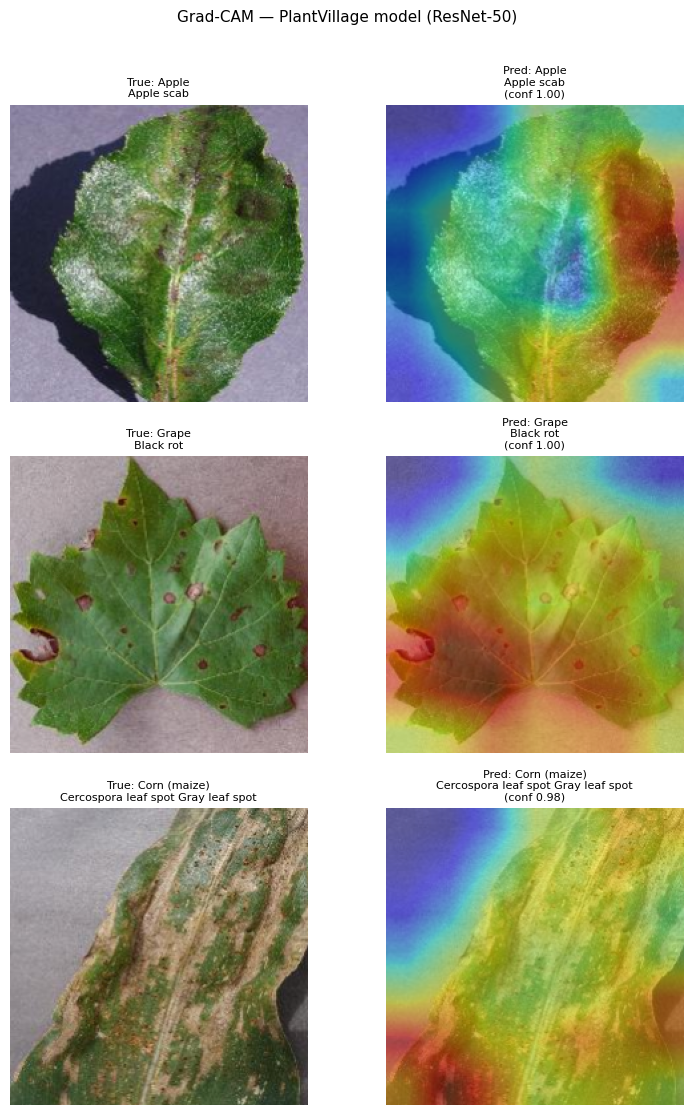

Saved gradcam_pv.png


In [6]:
fig_pv, axes_pv = plt.subplots(3, 2, figsize=(8, 11))

for row_idx, cls in enumerate(pv_targets):
    path       = pv_samples[cls]
    t          = load_img_tensor(path)
    img_rgb    = tensor_to_display(t)

    with torch.enable_grad():
        cam = pv_cam(t.clone().requires_grad_(False))

    with torch.inference_mode():
        logits = pv_model(t.to(DEVICE))
        probs  = logits.softmax(1)
        pred_idx  = int(probs.argmax(1).item())
        conf      = float(probs[0, pred_idx].item())
        pred_name = pv_classes[pred_idx].replace("___", "\n").replace("_", " ")

    short_cls = cls.replace("___", "\n").replace("_", " ")
    plot_panel(axes_pv[row_idx], img_rgb, cam, f"True: {short_cls}", pred_name, conf)

fig_pv.suptitle("Grad-CAM — PlantVillage model (ResNet-50)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "models" / "gradcam_pv.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved gradcam_pv.png")

## 4. Plant Pathology panels (PP ResNet-50)

In [7]:
import pandas as pd

# Load PP model
pp_ckpt    = torch.load(ROOT / "models" / "resnet50_pp_best.pt", map_location=DEVICE)
pp_classes = pp_ckpt["classes"]

pp_model = build_model(
    arch="resnet50", num_classes=len(pp_classes),
    task="multi", pretrained=False,
).to(DEVICE)
pp_model.load_state_dict(pp_ckpt["model_state"])

pp_cam = GradCAM(pp_model, pp_model.layer4[-1])
print(f"Loaded PP model — {len(pp_classes)} labels: {pp_classes}")

Loaded PP model — 6 labels: ['scab', 'healthy', 'frog_eye_leaf_spot', 'complex', 'rust', 'powdery_mildew']


In [8]:
PP_IMG_DIR = ROOT / "data" / "plantpathology" / "train_images"
pp_csv     = pd.read_csv(ROOT / "data" / "plantpathology" / "train.csv")

# Pick 2 diseased images and 1 healthy image
diseased_df = pp_csv[~pp_csv["labels"].astype(str).str.contains("healthy")]
healthy_df  = pp_csv[pp_csv["labels"].astype(str).str.strip() == "healthy"]

random.seed(SEED)
diseased_rows = diseased_df.sample(2, random_state=SEED)
healthy_rows  = healthy_df.sample(1,  random_state=SEED)
pp_rows = list(diseased_rows.itertuples()) + list(healthy_rows.itertuples())

for r in pp_rows:
    print(f"{r.image}  ->  {r.labels}")

bcead055c9062dd3.jpg  ->  complex
e0b24ee576e04f68.jpg  ->  powdery_mildew complex
a98081d51bdede0f.jpg  ->  healthy


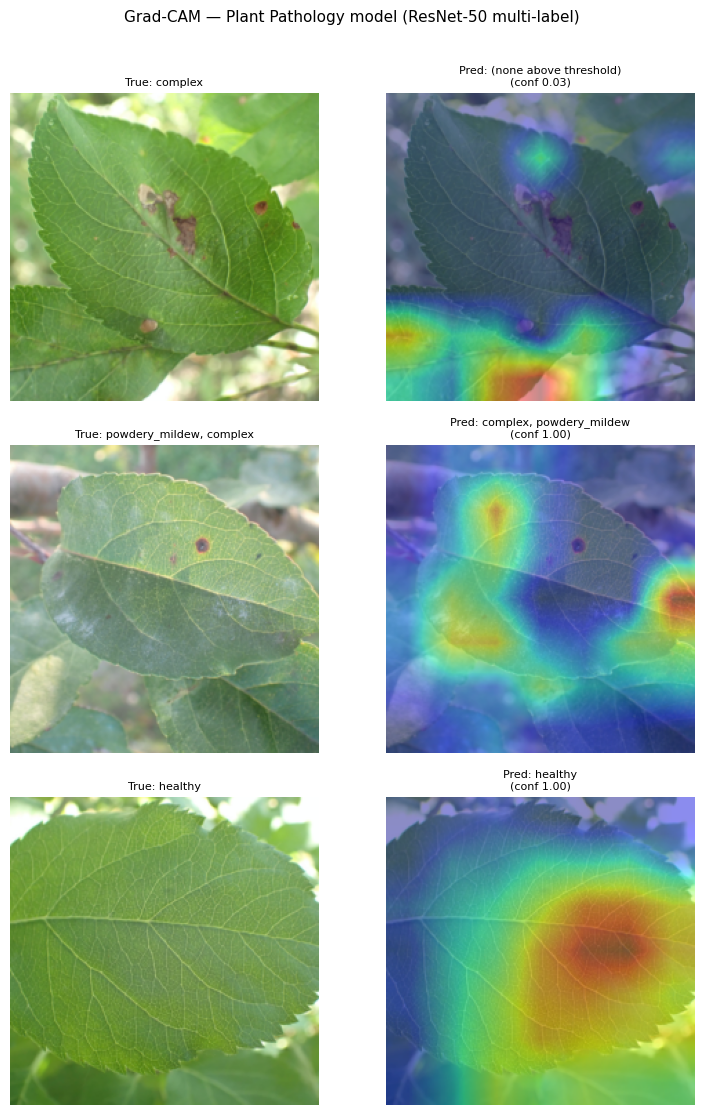

Saved gradcam_pp.png


In [9]:
THRESHOLD = 0.5

fig_pp, axes_pp = plt.subplots(3, 2, figsize=(8, 11))

for row_idx, row in enumerate(pp_rows):
    path    = PP_IMG_DIR / row.image
    t       = load_img_tensor(path)
    img_rgb = tensor_to_display(t)

    # For multi-label Grad-CAM use the highest-scoring label as the target class
    with torch.inference_mode():
        logits    = pp_model(t.to(DEVICE))
        scores    = logits.sigmoid()
        top_idx   = int(scores.argmax(1).item())
        top_score = float(scores[0, top_idx].item())
        pred_lbls = [pp_classes[i] for i, s in enumerate(scores[0].tolist()) if s >= THRESHOLD]
        pred_str  = ", ".join(pred_lbls) if pred_lbls else "(none above threshold)"

    with torch.enable_grad():
        cam = pp_cam(t.clone(), class_idx=top_idx)

    true_str = str(row.labels).replace(" ", ", ")
    plot_panel(axes_pp[row_idx], img_rgb, cam,
               f"True: {true_str}", pred_str, top_score)

fig_pp.suptitle("Grad-CAM — Plant Pathology model (ResNet-50 multi-label)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "models" / "gradcam_pp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved gradcam_pp.png")

## 5. Combined figure

Stitch both grids into a single wide figure saved as `gradcam_examples.png`.

In [10]:
from PIL import Image as PILImage

pv_img = PILImage.open(ROOT / "models" / "gradcam_pv.png")
pp_img = PILImage.open(ROOT / "models" / "gradcam_pp.png")

# Stack side by side (same height — resize pp to match pv height)
target_h = pv_img.height
pp_img   = pp_img.resize(
    (int(pp_img.width * target_h / pp_img.height), target_h),
    PILImage.LANCZOS,
)

combined = PILImage.new("RGB", (pv_img.width + pp_img.width, target_h), (255, 255, 255))
combined.paste(pv_img, (0, 0))
combined.paste(pp_img, (pv_img.width, 0))
combined.save(ROOT / "models" / "gradcam_examples.png")
print(f"Combined figure saved: {combined.size[0]}x{combined.size[1]} px")

Combined figure saved: 2094x1673 px


In [11]:
# Clean up hooks
pv_cam.remove()
pp_cam.remove()
print("Hooks removed.")

Hooks removed.
